In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json

import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), ".")))

from warehouse.warehouse_route import Warehouse
from warehouse.route_optimization import RouteOptimizer


In [2]:
show_plots = True

Loading warehouse layout from ../layout/warehouse_layout.json, image path: ../layout/warehouse-layout.png
Row 4 Bay 1 is not available
Row 4 Bay 2 is not available


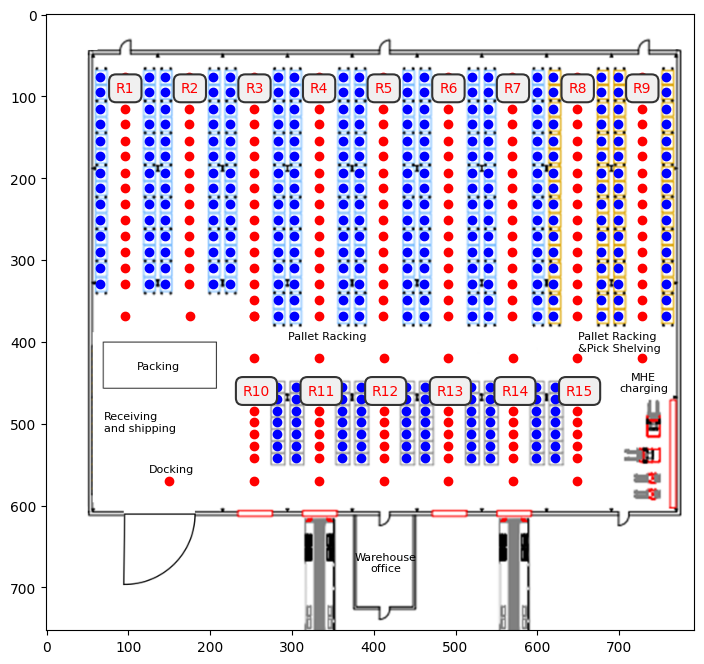

In [10]:
WH = Warehouse().load_from_json("../layout/warehouse_layout.json")


if show_plots:
    fig,ax = WH.show_layout()
    WH.show_locations(ax)
    WH.show_access_points(ax)
    #WH.show_connections(ax)
    #WH.show_edges(ax)
    #WH.show_picking_points(ax)
    WH.show_labels(ax)

In [4]:
optimizer = RouteOptimizer(WH)

In [5]:
spots = ["Docking", "R12_B3_C1", "R3_B5_C2", "R3_B8_C1"]

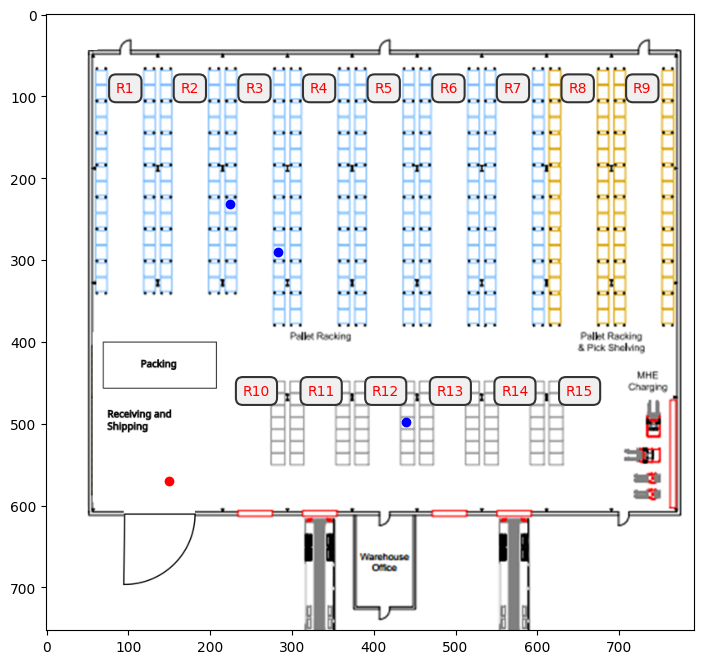

In [8]:
fig,ax = WH.show_layout()
WH.show_spots(ax, spots)
WH.show_labels(ax)

In [9]:
optimizer.set_route(spots)


In [10]:
optimizer.graph

{'Docking': {'AP_10': 104.0},
 'AP_1': {'AP_2': 79.0},
 'AP_2': {'AP_1': 79.0, 'AP_3A': 79.0},
 'AP_3A': {'AP_2': 79.0,
  'PICK_3_5': 78.00160254764,
  'PICK_3_8': 136.0009191145413,
  'AP_3': 52.0},
 'AP_3': {'AP_3A': 52.0, 'AP_4': 79.0, 'AP_10': 150.0},
 'AP_4': {'AP_3': 79.0, 'AP_5': 79.0, 'AP_11': 150.0},
 'AP_5': {'PICK_12_4': 78.5, 'AP_4': 79.0, 'AP_6': 79.0, 'AP_12': 150.0},
 'AP_6': {'AP_5': 79.0, 'AP_7': 79.0, 'AP_13': 150.0},
 'AP_7': {'AP_6': 79.0, 'AP_8': 79.0, 'AP_14': 150.0},
 'AP_8': {'AP_7': 79.0, 'AP_9': 79.0, 'AP_15': 150.0},
 'AP_9': {'AP_8': 79.0},
 'AP_10': {'AP_3': 150.0, 'AP_11': 79.0, 'Docking': 104.0},
 'AP_11': {'AP_4': 150.0, 'AP_10': 79.0, 'AP_12': 79.0},
 'AP_12': {'AP_5': 150.0, 'PICK_12_4': 71.5, 'AP_11': 79.0, 'AP_13': 79.0},
 'AP_13': {'AP_6': 150.0, 'AP_12': 79.0, 'AP_14': 79.0},
 'AP_14': {'AP_7': 150.0, 'AP_13': 79.0, 'AP_15': 79.0},
 'AP_15': {'AP_8': 150.0, 'AP_14': 79.0},
 'PICK_12_4': {'AP_5': 78.5, 'AP_12': 71.5},
 'PICK_3_5': {'AP_3A': 78.00160

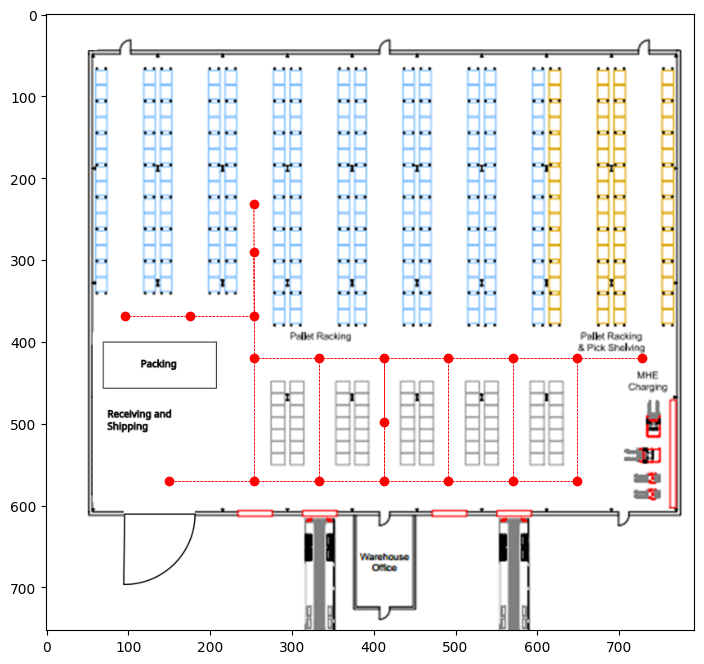

In [12]:
fig,ax = WH.show_layout()
active_nodes = optimizer.graph.keys()
WH.show_spots(ax, active_nodes)
WH.show_connections(ax, active_nodes)

In [13]:
path = optimizer.optimize_route(round_trip=True)

In [14]:
path

{'distance': np.float64(1200.0025216621812),
 'path': ['Docking',
  'AP_10',
  'AP_3',
  'AP_3A',
  'PICK_3_8',
  'PICK_3_5',
  'AP_3A',
  'AP_3',
  'AP_4',
  'AP_5',
  'PICK_12_4',
  'AP_12',
  'AP_11',
  'AP_10',
  'Docking']}

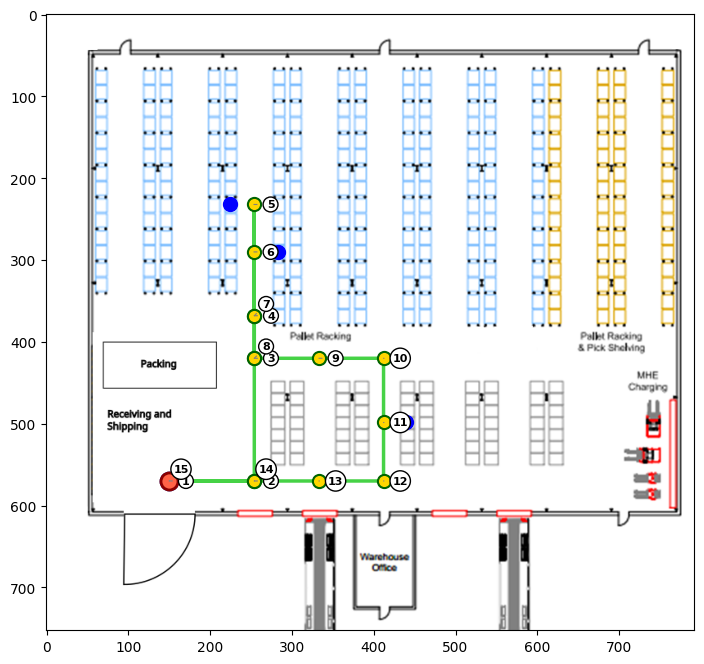

In [ ]:
fig,ax = WH.show_layout()
WH.show_path(ax, path["path"])
WH.show_spots(ax, spots, markersize=10)
